In [13]:
import json
import psycopg2
import numpy as np
import pandas as pd
from datetime import datetime

%matplotlib widget 
import matplotlib.pyplot as plt
import matplotlib.dates as md

In [14]:
# define objects `db_conn`, `db_cursor` to access the CAGE SC DB.

with open("../config.json") as f:
    config = json.load(f)

db_conn = psycopg2.connect(dbname=config["db_name"], 
                            user=config["db_user"], 
                            password=config["password"], 
                            host=config["cage_daq"])
db_cursor = db_conn.cursor()

In [15]:
""" 
grab the current list of endpoints
"""
cmd = "SELECT * FROM endpoint_id_map;"
db_cursor.execute(cmd)
record = db_cursor.fetchall()
df_end = pd.DataFrame(record, columns=["row","endpoint_name","data_type"])
# display(df_end)

In [16]:
def pandas_db_query(endpoints, t_earlier, t_later, df_file=None):
    """
    general use function.
    for each endpoint and start/stop dates, create a DataFrame.
    if `df_file` is set, write the output to an HDF5 file.
    """
    dfs = {}

    for pt in endpoints:
        query = f"SELECT value_cal, timestamp FROM numeric_data "
        query += f"WHERE endpoint_name='{pt}'"
        query += f"AND timestamp>='{t_earlier}' and timestamp<='{t_later}';"
        
        db_cursor.execute(query)
        record = db_cursor.fetchall()
        df = pd.DataFrame(record, columns=[pt, 'timestamp']) 
        dfs[pt] = df
        
        if df_file is not None:
            df.to_hdf(df_file, key=pt)
            
    return dfs

In [17]:
# -- get cooldown data

endpoints = ['cage_pressure', 'cage_coldPlate_temp', 'cage_ln_level', 'cage_motor_temp', 'cage_topHat_temp']

df_file = "./plots/cooldown_aug_2019.h5"
t_earlier_aug = '2019-08-31T00:00'
t_later_aug = '2019-09-05T00:00'
pandas_db_query(endpoints, t_earlier_aug, t_later_aug, df_file)
    
df_file = "./plots/cooldown_sep_2022.h5"
t_earlier_aug = '2022-10-06T00:00'
t_later_aug = '2022-10-09T16:46'
pandas_db_query(endpoints, t_earlier_aug, t_later_aug, df_file)

# df_file = "./plots/cooldown_sep.h5"
# t_earlier_sep = '2019-09-26T00:00'
# t_later_sep = '2019-10-01T00:00'
# pandas_db_query(endpoints, t_earlier_sep, t_later_sep, df_file)

{'cage_pressure':       cage_pressure                  timestamp
 0      9.225249e-05 2022-10-06 18:16:09.677748
 1      9.225249e-05 2022-10-06 18:16:40.015510
 2      9.197047e-05 2022-10-06 18:17:10.319825
 3      9.168930e-05 2022-10-06 18:17:40.442408
 4      9.197047e-05 2022-10-06 18:18:10.627713
 ...             ...                        ...
 8389   6.867522e-08 2022-10-09 16:43:29.591149
 8390   6.878043e-08 2022-10-09 16:43:59.784198
 8391   6.825596e-08 2022-10-09 16:44:29.981218
 8392   6.825596e-08 2022-10-09 16:45:00.174648
 8393   6.815155e-08 2022-10-09 16:45:30.427140
 
 [8394 rows x 2 columns],
 'cage_coldPlate_temp':       cage_coldPlate_temp                  timestamp
 0               26.038918 2022-10-06 18:16:09.912069
 1               26.106591 2022-10-06 18:16:40.203208
 2               26.106591 2022-10-06 18:17:10.511533
 3               26.106591 2022-10-06 18:17:40.815521
 4               26.072754 2022-10-06 18:18:11.009718
 ...                   ...      

Keys: ['/cage_coldPlate_temp', '/cage_ln_level', '/cage_motor_temp', '/cage_pressure', '/cage_topHat_temp']


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …
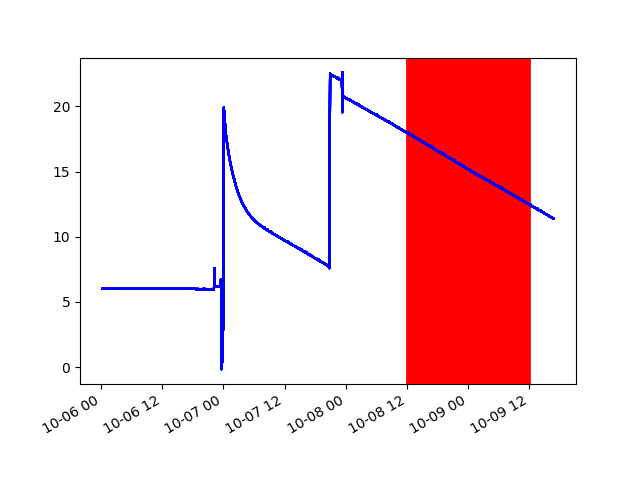

In [54]:
# df_file = "./plots/cooldown_aug_2019.h5"

df_file = "./plots/cooldown_sep_2022.h5"

with pd.HDFStore(df_file, 'r') as f:
    print("Keys:", f.keys())

ln_level = pd.read_hdf(df_file, key='/cage_ln_level')
motor_temp = pd.read_hdf(df_file, key='/cage_motor_temp')
tophat_temp = pd.read_hdf(df_file, key='/cage_topHat_temp')
cp_temp = pd.read_hdf(df_file, key='/cage_coldPlate_temp')
pressure = pd.read_hdf(df_file, key='/cage_pressure')
# display(ln_level)

plt.plot(ln_level["timestamp"], ln_level["cage_ln_level"], '-b')

# I see two regions - one of faster  consumption at the beginning of cooldown (expo decay),
# and a steady state linear consumption rate.
tlo, thi = '2022-10-08 12', '2022-10-09 12'

# plt.axvspan(pd.to_datetime(tlo), pd.to_datetime(thi), color='r', alpha=0.4)
plt.axvspan(pd.Timestamp(tlo), pd.Timestamp(thi), color='r', alpha=0.4)

# plt.gcf().autofmt_xdate() # rotates labels
plt.show()

In [53]:
# compute linear region consumption
# old note on usage rate: It took about 12 hours to reach the lowest temperature. The first 6 hours 
# of cooling used about 5 kg of LN, and it seems like the average LN useage was 4 kg/day after that.

# note from Joule:
# https://elog.legend-exp.org/UWScanner/266 
# Note: with 4kg left in the dewar, the cold-plate had started warming up since the cold finger
# was no longer sitting in LN. Tare'd the scale so that when it's close to 0.0 kg in the future 
# it's not actually empty, but the cold finger will have just gotten out of the LN bath. 

ln_interval = ln_level.query(f"timestamp >= '{tlo}' and timestamp <= '{thi}'").copy()
display(ln_interval)

ln_interval_duration = (ln_interval.iloc[-1]['timestamp'] - ln_interval.iloc[0]['timestamp']).seconds
ln_interval_duration *= 1/86400

ln_level_diff = ln_interval.iloc[-1]['cage_ln_level'] - ln_interval.iloc[0]['cage_ln_level']

ln_consumption_rate = ln_level_diff / ln_interval_duration
print(f'Consumption rate: {ln_consumption_rate :.2f}  lbs(or kg?) per day', )


,cage_ln_level,timestamp
548,17.95,2022-10-08 12:05:48.510275
549,18.00,2022-10-08 12:06:18.672601
550,17.95,2022-10-08 12:06:48.855680
551,17.90,2022-10-08 12:18:50.072206
552,17.85,2022-10-08 12:31:51.449808
...,...,...
712,12.70,2022-10-09 10:59:39.815363
713,12.65,2022-10-09 11:12:11.088627
714,12.60,2022-10-09 11:25:42.507020
715,12.55,2022-10-09 11:39:13.880242


Consumption rate: -5.50  lbs(or kg?) per day
